In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import time

from tqdm import tqdm

import numpy as np
import pandas as pd

import hyperopt.hp as hp

from sklearn.model_selection import train_test_split

from catboost import CatBoostClassifier

from sklift.datasets import fetch_x5
from sklift.models import ClassTransformation, TwoModels
from sklift.metrics import qini_auc_score, uplift_at_k

from causalml.inference.tree import UpliftTreeClassifier as UpliftTreeClassifierCM

from upninja.dml.UpliftTreeClassifierDML import UpliftTreeClassifierDML
from upninja.tune.Selection import UpliftTune

import matplotlib.pyplot as plt
import seaborn as sns

Failed to import duecredit due to No module named 'duecredit'


In [3]:
SEED = 8

In [4]:
%%time

dataset = fetch_x5()
dataset.data.keys()

CPU times: user 25.2 s, sys: 4.81 s, total: 30 s
Wall time: 32.7 s


dict_keys(['clients', 'train', 'purchases'])

In [5]:
%%time

print(f'Dataset type: {type(dataset)}\n')
print(f'Dataset features shape: {dataset.data['clients'].shape}')
print(f'Dataset features shape: {dataset.data['train'].shape}')
print(f'Dataset target shape: {dataset.target.shape}')
print(f'Dataset treatment shape: {dataset.treatment.shape}')

Dataset type: <class 'sklearn.utils._bunch.Bunch'>

Dataset features shape: (400162, 5)
Dataset features shape: (200039, 1)
Dataset target shape: (200039,)
Dataset treatment shape: (200039,)
CPU times: user 97 μs, sys: 93 μs, total: 190 μs
Wall time: 193 μs


In [6]:
%%time

# Извлечение данных
df_clients = dataset.data['clients'].set_index('client_id')
df_train = pd.concat([dataset.data['train'], dataset.treatment , dataset.target], axis=1).set_index('client_id')
indices_test = pd.Index(set(df_clients.index) - set(df_train.index))

# Извлечение признаков
df_features = df_clients.copy()
df_features['first_issue_time'] = \
    (pd.to_datetime(df_features['first_issue_date'])
     - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')
df_features['first_redeem_time'] = \
    (pd.to_datetime(df_features['first_redeem_date'])
     - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')
df_features['issue_redeem_delay'] = df_features['first_redeem_time'] \
    - df_features['first_issue_time']
df_features = df_features.drop(['first_issue_date', 'first_redeem_date'], axis=1)

indices_learn, indices_valid = train_test_split(df_train.index, test_size=0.3, random_state=SEED)

CPU times: user 186 ms, sys: 32.9 ms, total: 219 ms
Wall time: 222 ms


In [7]:
%%time

X_train = df_features.loc[indices_learn, :]
y_train = df_train.loc[indices_learn, 'target']
treat_train = df_train.loc[indices_learn, 'treatment_flg']

X_val = df_features.loc[indices_valid, :]
y_val = df_train.loc[indices_valid, 'target']
treat_val =  df_train.loc[indices_valid, 'treatment_flg']

X_train_full = df_features.loc[df_train.index, :]
y_train_full = df_train.loc[:, 'target']
treat_train_full = df_train.loc[:, 'treatment_flg']

X_test = df_features.loc[indices_test, :]

X_train['gender'] = X_train['gender'].map({'F': 0, 'U': -1, 'M': 1})
X_val['gender'] = X_val['gender'].map({'F': 0, 'U': -1, 'M': 1})
X_test['gender'] = X_test['gender'].map({'F': 0, 'U': -1, 'M': 1})

X_train.fillna(-1.0, inplace=True)
X_val.fillna(-1.0, inplace=True)
X_test.fillna(-1.0, inplace=True)

cat_features = ['gender']

CPU times: user 196 ms, sys: 5.49 ms, total: 202 ms
Wall time: 201 ms


In [8]:
def get_bootstrap_samples(data, countSamples):
    ind = np.random.randint(0, len(data) - 1, (countSamples, len(data)))
    samples = np.array(data)[ind]
    return samples, ind

def stat_intervals(stat, alpha):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [9]:
def stat_intervals_qini(b_samples, b_indexes, model):
    stat = []
    for s, i in tqdm(zip(b_samples, b_indexes)):
        pred = model.predict(X_val.iloc[i])
        q = qini_auc_score(y_true=y_val.iloc[i], uplift=pred, treatment=treat_val.iloc[i])
        stat.append(q)
    return stat_intervals(stat, 0.05), stat

def stat_intervals_qini_causal(b_samples, b_indexes, model):
    stat = []
    for s, i in tqdm(zip(b_samples, b_indexes)):
        pred = model.predict(X_val_np[i])[:, 0]
        q = qini_auc_score(y_true=y_val_np[i], uplift=pred, treatment=treat_val.iloc[i])
        stat.append(q)
    return stat_intervals(stat, 0.05), stat

In [10]:
diff_func = lambda uplift_pred_1, uplift_pred_2: qini_auc_score(y_val, uplift_pred_1, treat_val) - qini_auc_score(y_val, uplift_pred_2, treat_val)

def qini_diff_test(qini_1, uplift_1, qini_2, uplift_2, b_samples_count, diff_func=diff_func):
    delta = qini_1 - qini_2
    obs_diff = diff_func(uplift_1, uplift_2)
    if obs_diff >= 0:
        p_two_sided = 2 * (np.sum(delta <= 0) / b_samples_count)
    else:
        p_two_sided = 2 * (np.sum(delta >= 0) / b_samples_count)
    return min(1.0, p_two_sided)

In [11]:
np.random.seed(SEED)

bootstrap_samples, bootstrap_indexes = get_bootstrap_samples(X_val, 1000)

In [12]:
models_results = {
    'approach': [],
    'uplift@30%': [],
    'qini-auc': [],
    'CPU time(minutes)': [],
    '95% qini-auc CI': []
}

## ⭐ Scikit-uplift модели 

### DDR

In [13]:
%%time

cb_params = cb_hp_space = {
    'iterations': hp.uniformint('iterations', 100, 2500),
    'depth': hp.uniformint('depth', 2, 10),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'l2_leaf_reg': hp.uniform('l2_leaf_reg', 1, 10),
    'verbose': False,
    'thread_count': -1,
    'random_state': SEED
}

cb_tune = UpliftTune(
    base_model_class=CatBoostClassifier,
    uplift_model_class=TwoModels,
    data=X_train,
    target=y_train,
    treatment=treat_train,
    space=cb_params,
    verbose=True,
    max_evals=10
)

t_time_start = time.process_time_ns()
cb_tuned = cb_tune.tune()['best_params']
t_time_end = time.process_time_ns()

100%|███████| 10/10 [03:54<00:00, 23.44s/trial, best loss: -0.04744095603742767]
Optimization completed. Best score: 0.0474
Best parameters: {'depth': 7, 'iterations': 230, 'l2_leaf_reg': 7.9424273583625355, 'learning_rate': 0.14742669669812852, 'random_state': 8, 'thread_count': -1, 'verbose': False}
CPU times: user 25min 11s, sys: 5min 30s, total: 30min 41s
Wall time: 3min 54s


In [14]:
%%time

tm = TwoModels(
    estimator_trmnt=CatBoostClassifier(**cb_tuned), 
    estimator_ctrl=CatBoostClassifier(**cb_tuned), 
    method='ddr_control'
)

f_time_start = time.process_time_ns()
tm = tm.fit(
    X_train, y_train, treat_train,
    estimator_trmnt_fit_params={'cat_features': cat_features}, 
    estimator_ctrl_fit_params={'cat_features': cat_features}
)
f_time_end = time.process_time_ns()

uplift_tm = tm.predict(X_val)

tm_score = uplift_at_k(y_true=y_val, uplift=uplift_tm, treatment=treat_val, strategy='by_group', k=0.3)
tm_score_q = qini_auc_score(y_true=y_val, uplift=uplift_tm, treatment=treat_val)

CPU times: user 35.5 s, sys: 6.58 s, total: 42.1 s
Wall time: 5.06 s


In [15]:
models_results['approach'].append('DDR')
models_results['uplift@30%'].append(tm_score)
models_results['qini-auc'].append(tm_score_q)
models_results['CPU time(minutes)'].append((t_time_end - t_time_start + f_time_end - f_time_start) / (1000000000 * 60))

In [16]:
ci, tm_stat_q = stat_intervals_qini(bootstrap_samples, bootstrap_indexes, tm)

models_results['95% qini-auc CI'].append(f'[{ci[0]:.6f}, {ci[1]:.6f}]')

1000it [00:38, 25.97it/s]


### Class Transformation

In [17]:
%%time

cb_params = cb_hp_space = {
    'iterations': hp.uniformint('iterations', 100, 2500),
    'depth': hp.uniformint('depth', 2, 10),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'l2_leaf_reg': hp.uniform('l2_leaf_reg', 1, 10),
    'verbose': False,
    'thread_count': -1,
    'random_state': SEED
}

cb_tune = UpliftTune(
    base_model_class=CatBoostClassifier,
    uplift_model_class=ClassTransformation,
    data=X_train,
    target=y_train,
    treatment=treat_train,
    space=cb_params,
    verbose=True,
    max_evals=10
)

t_time_start = time.process_time_ns()
cb_tuned = cb_tune.tune()['best_params']
t_time_end = time.process_time_ns()

100%|███████| 10/10 [02:54<00:00, 17.41s/trial, best loss: -0.04954288228464684]
Optimization completed. Best score: 0.0495
Best parameters: {'depth': 2, 'iterations': 2166, 'l2_leaf_reg': 6.474242459540229, 'learning_rate': 0.06708005741019658, 'random_state': 8, 'thread_count': -1, 'verbose': False}
CPU times: user 18min 29s, sys: 3min 41s, total: 22min 11s
Wall time: 2min 54s


In [18]:
%%time

ct = ClassTransformation(CatBoostClassifier(**cb_tuned))
f_time_start = time.process_time_ns()
ct = ct.fit(X_train, y_train, treat_train, estimator_fit_params={'cat_features': cat_features})
f_time_end = time.process_time_ns()

uplift_ct = ct.predict(X_val)

ct_score = uplift_at_k(y_true=y_val, uplift=uplift_ct, treatment=treat_val, strategy='by_group', k=0.3)
ct_score_q = qini_auc_score(y_true=y_val, uplift=uplift_ct, treatment=treat_val)

CPU times: user 2min 55s, sys: 16.1 s, total: 3min 11s
Wall time: 23.8 s


In [19]:
models_results['approach'].append('ClassTransformation')
models_results['uplift@30%'].append(ct_score)
models_results['qini-auc'].append(ct_score_q)
models_results['CPU time(minutes)'].append((t_time_end - t_time_start + f_time_end - f_time_start) / (1000000000 * 60))

In [20]:
ci, ct_stat_q = stat_intervals_qini(bootstrap_samples, bootstrap_indexes, ct)

models_results['95% qini-auc CI'].append(f'[{ci[0]:.6f}, {ci[1]:.6f}]')

1000it [00:37, 26.39it/s]


## ⭐ CausalML

In [21]:
X_train_np, X_val_np, y_train_np, y_val_np, treat_train_str, treat_val_str = (
    X_train.values, X_val.values,
    y_train.values, y_val.values,
    np.where(treat_train == 1, 'treatment', 'control'),
    np.where(treat_val == 1, 'treatment', 'control')
)

In [22]:
%%time

space = {
    'evaluationFunction': hp.choice('evaluationFunction', ['KL', 'ED', 'CTS']),
    'control_name': 'control',
    'min_samples_leaf': hp.uniformint('min_samples_leaf', 20, 500),
    'max_depth': hp.uniformint('max_depth', 3, 20),
    'min_samples_treatment': hp.uniformint('min_samples_treatment', 10, 100),
    'random_state': SEED
}

causal_tune = UpliftTune(
    uplift_model_class=UpliftTreeClassifierCM,
    data=X_train_np,
    target=y_train_np,
    treatment=treat_train_str,
    space=space,
    verbose=True,
    max_evals=10
)

t_time_start = time.process_time_ns()
causal_tuned = causal_tune.tune()['best_params']
t_time_end = time.process_time_ns()

100%|████████| 10/10 [00:12<00:00,  1.23s/trial, best loss: -0.0371311432400497]
Optimization completed. Best score: 0.0371
Best parameters: {'control_name': 'control', 'evaluationFunction': 'KL', 'max_depth': 13, 'min_samples_leaf': 122, 'min_samples_treatment': 46, 'random_state': 8}
CPU times: user 12 s, sys: 252 ms, total: 12.3 s
Wall time: 12.3 s


In [23]:
%%time

causalml = UpliftTreeClassifierCM(**causal_tuned)
causalml.fit(X_train_np, treat_train_str, y_train_np)

f_time_start = time.process_time_ns()
uplift_causalml = causalml.predict(X_val_np)[:, 0]
f_time_end = time.process_time_ns()

causalml_score = uplift_at_k(y_true=y_val, uplift=uplift_causalml, treatment=treat_val, strategy='by_group', k=0.3)
causalml_score_q = qini_auc_score(y_true=y_val, uplift=uplift_causalml, treatment=treat_val)

CPU times: user 740 ms, sys: 15.3 ms, total: 756 ms
Wall time: 762 ms


In [24]:
models_results['approach'].append('CausalML')
models_results['uplift@30%'].append(causalml_score)
models_results['qini-auc'].append(causalml_score_q)
models_results['CPU time(minutes)'].append((t_time_end - t_time_start + f_time_end - f_time_start) / (1000000000 * 60))

In [25]:
ci, causalml_stat_q = stat_intervals_qini_causal(bootstrap_samples, bootstrap_indexes, causalml)

models_results['95% qini-auc CI'].append(f'[{ci[0]:.6f}, {ci[1]:.6f}]')

1000it [02:13,  7.51it/s]


## ⭐ DML Tree

In [26]:
%%time

space = {
    'min_samples': hp.uniformint('min_samples', 20, 500),
    'max_depth': hp.uniformint('max_depth', 3, 20),
    'bins': hp.uniformint('bins', 5, 30),
    'min_samples_treatment': hp.uniformint("min_samples_treatment", 10, 100),
    'random_state': SEED
}

dml_tune = UpliftTune(
    uplift_model_class=UpliftTreeClassifierDML,
    data=X_train,
    target=y_train,
    treatment=treat_train,
    space=space,
    verbose=True,
    max_evals=10
)

t_time_start = time.process_time_ns()
dml_tuned = dml_tune.tune()['best_params']
t_time_end = time.process_time_ns()

100%|███████| 10/10 [00:09<00:00,  1.10trial/s, best loss: -0.05934611229239665]
Optimization completed. Best score: 0.0593
Best parameters: {'bins': 13, 'max_depth': 16, 'min_samples': 418, 'min_samples_treatment': 16, 'random_state': 8}
CPU times: user 9.02 s, sys: 93.2 ms, total: 9.11 s
Wall time: 9.12 s


In [27]:
%%time

dml = UpliftTreeClassifierDML(**dml_tuned)

f_time_start = time.process_time_ns()
dml = dml.fit(X_train, y_train, treat_train)
f_time_end = time.process_time_ns()

uplift_dml = dml.predict(X_val)

dml_score = uplift_at_k(y_true=y_val, uplift=uplift_dml, treatment=treat_val, strategy='by_group', k=0.3)
dml_score_q = qini_auc_score(y_true=y_val, uplift=uplift_dml, treatment=treat_val)

CPU times: user 596 ms, sys: 7.59 ms, total: 604 ms
Wall time: 603 ms


In [28]:
models_results['approach'].append('DecisionTreeDML')
models_results['uplift@30%'].append(dml_score)
models_results['qini-auc'].append(dml_score_q)
models_results['CPU time(minutes)'].append((t_time_end - t_time_start + f_time_end - f_time_start) / (1000000000 * 60))

In [29]:
ci, dml_stat_q = stat_intervals_qini(bootstrap_samples, bootstrap_indexes, dml)

models_results['95% qini-auc CI'].append(f'[{ci[0]:.6f}, {ci[1]:.6f}]')

1000it [00:19, 50.94it/s]


In [30]:
pd.DataFrame(models_results)

,approach,uplift@30%,qini-auc,CPU time(minutes),95% qini-auc CI
0,DDR,0.057782,0.011263,31.394310,"[0.005918, 0.016879]"
1,ClassTransformation,0.067340,0.016352,25.371262,"[0.010740, 0.021253]"
2,CausalML,0.040462,0.002736,0.206877,"[-0.002653, 0.008050]"
3,DecisionTreeDML,0.063822,0.015249,0.161730,"[0.009709, 0.020600]"


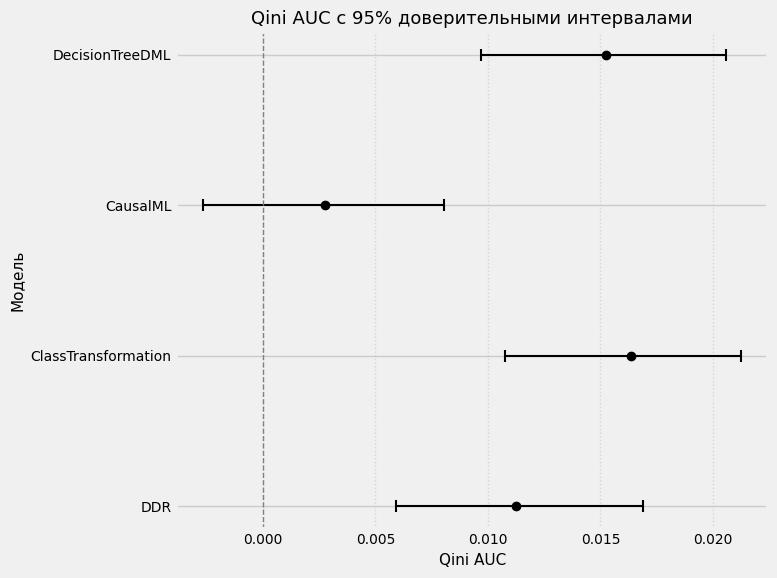

In [31]:
# наложение ДИ друг на друга
models = ['DDR', 'ClassTransformation', 'CausalML', 'DecisionTreeDML']
qini_means = [0.011263, 0.016352, 0.002736, 0.015249]
ci_lower = [0.005918, 0.010740, -0.002653, 0.009709]
ci_upper = [0.016879, 0.021253, 0.008050, 0.020600]

error_lower = [mean - low for mean, low in zip(qini_means, ci_lower)]
error_upper = [up - mean for mean, up in zip(qini_means, ci_upper)]

plt.figure(figsize=(8, 6))
plt.errorbar(
    qini_means, models,
    xerr=[error_lower, error_upper],
    fmt='o', color='black',
    capsize=4, capthick=1.5, elinewidth=1.5,
    markersize=6
)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.title('Qini AUC с 95% доверительными интервалами', fontsize=13)
plt.xlabel('Qini AUC', fontsize=11)
plt.ylabel('Модель', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', axis='x', alpha=0.7)
plt.tight_layout()
plt.show()

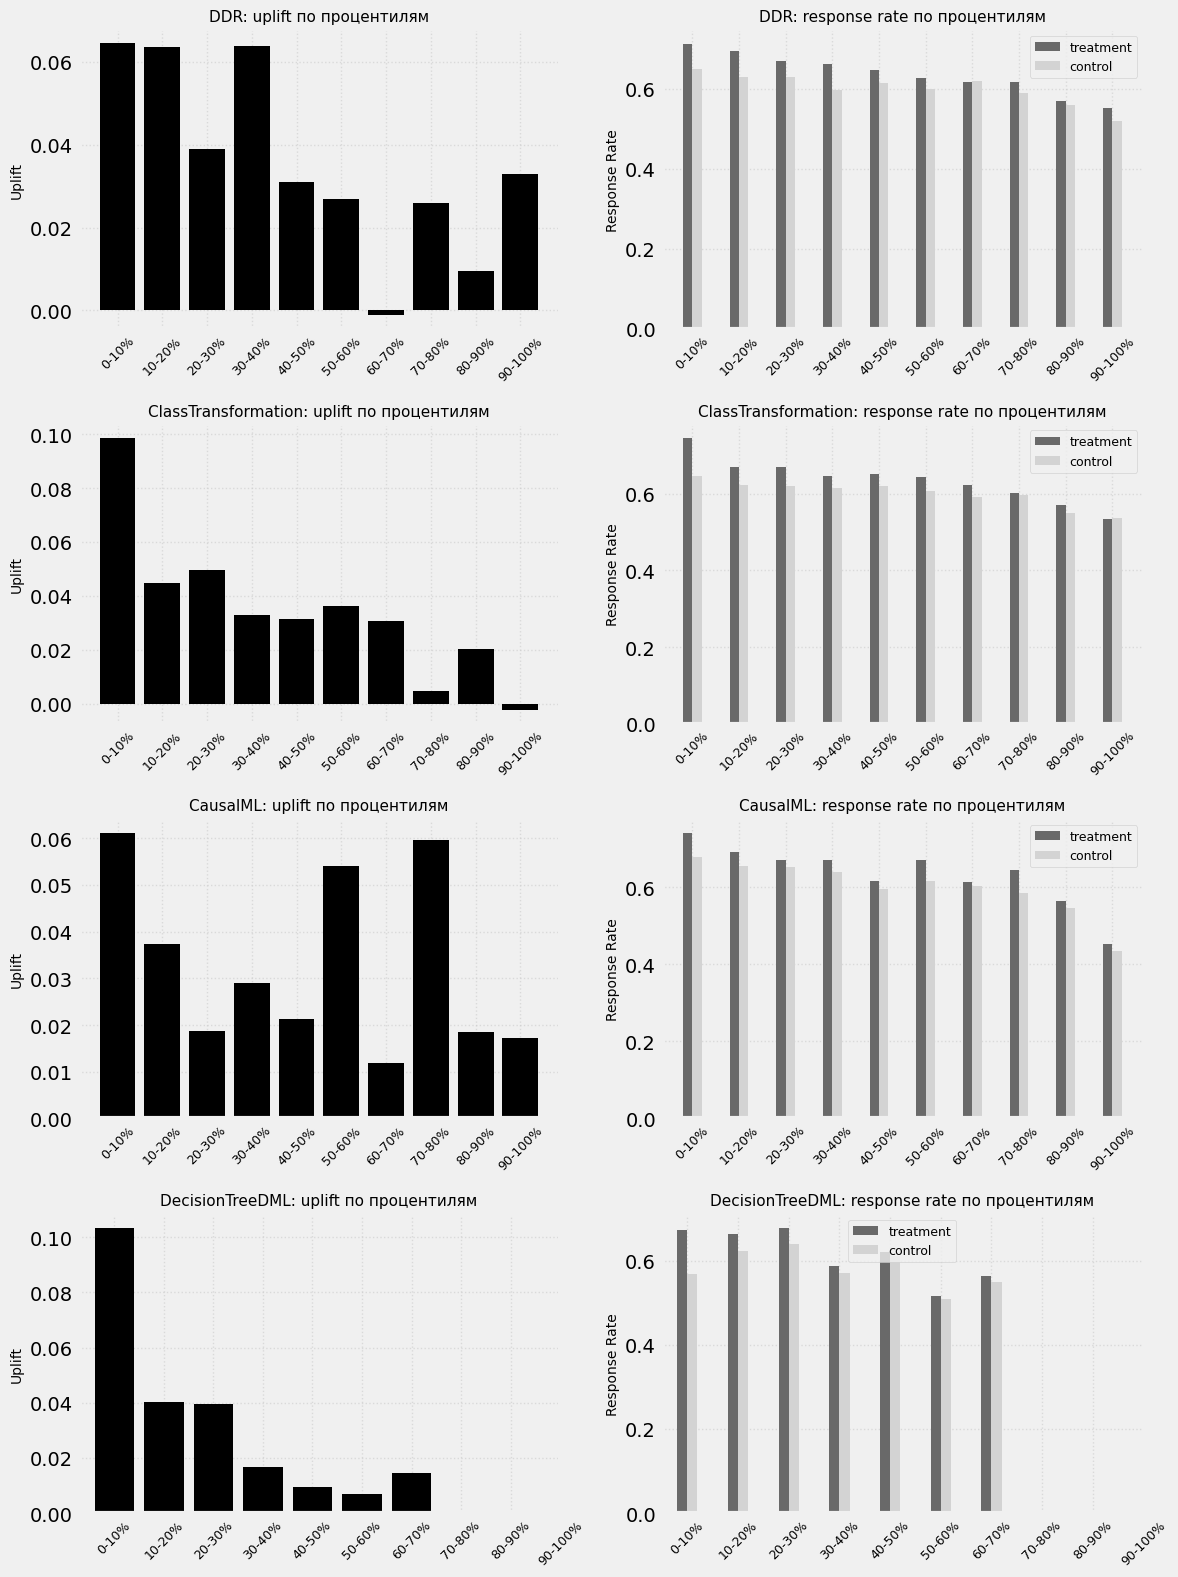

In [35]:
df = pd.DataFrame({
    'treatment': treat_val.values,
    'outcome': y_val.values
})

uplift_scores = {
    'DDR': uplift_tm,
    'ClassTransformation': uplift_ct,
    'CausalML': uplift_causalml,
    'DecisionTreeDML': uplift_dml
}

n_bins = 10
percentile_labels = [f"{i*10}-{(i+1)*10}%" for i in range(n_bins)]
x = np.arange(n_bins)

fig, axs = plt.subplots(len(uplift_scores), 2, figsize=(12, 4 * len(uplift_scores)), sharex=False)

for i, (model, scores) in enumerate(uplift_scores.items()):
    df['score'] = scores
    # лучшие клиенты -> первые децили
    df['percentile'] = pd.qcut(-df['score'], q=n_bins, labels=False, duplicates='drop')

    uplift_by_percentile = []
    treat_rates = []
    control_rates = []

    for p in range(n_bins):
        bin_df = df[df['percentile'] == p]
        treated = bin_df[bin_df['treatment'] == 1]['outcome']
        control = bin_df[bin_df['treatment'] == 0]['outcome']
        uplift = treated.mean() - control.mean()
        uplift_by_percentile.append(uplift)
        treat_rates.append(treated.mean())
        control_rates.append(control.mean())

    axs[i, 0].bar(x, uplift_by_percentile, color='black')
    axs[i, 0].set_title(f"{model}: uplift по процентилям", fontsize=11)
    axs[i, 0].set_ylabel("Uplift", fontsize=10)
    axs[i, 0].set_xticks(x)
    axs[i, 0].set_xticklabels(percentile_labels, rotation=45, fontsize=9)
    axs[i, 0].grid(True, linestyle=':', alpha=0.6)

    axs[i, 1].bar(x - 0.1, treat_rates, width=0.2, label='treatment', color='dimgray')
    axs[i, 1].bar(x + 0.1, control_rates, width=0.2, label='control', color='lightgray')
    axs[i, 1].set_title(f"{model}: response rate по процентилям", fontsize=11)
    axs[i, 1].set_ylabel("Response Rate", fontsize=10)
    axs[i, 1].set_xticks(x)
    axs[i, 1].set_xticklabels(percentile_labels, rotation=45, fontsize=9)
    axs[i, 1].legend(fontsize=9)
    axs[i, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [33]:
models = {'DDR': [uplift_tm, tm_stat_q],
          'ClassTransformation': [uplift_ct, ct_stat_q],
          'CausalML': [uplift_causalml, causalml_stat_q],
          'DecisionTreeDML': [uplift_dml, dml_stat_q]}

p_values = pd.DataFrame(np.zeros((4, 4)), columns=models.keys(), index=models.keys())

for model_1 in models.keys():
    for model_2 in models.keys():
        qini_1 = np.array(models[model_1][1])
        uplift_1 = models[model_1][0]
        qini_2 = np.array(models[model_2][1])
        uplift_2 = models[model_2][0]
        p_value = qini_diff_test(qini_1, uplift_1, qini_2, uplift_2, 1000)
        p_values.loc[model_1, model_2] = p_value

<b>Описание теста и его интерпретация</b>:<br>
<b>$H_0:$</b> Модель A и модель B имеют равные значения qini-auc(разница qini-auc-a и qini-auc-b = 0);<br>
<b>$H_1:$</b> Модель A и модель B имеют различные значения qini-auc(разница qini-auc-a и qini-auc-b != 0);<br>

Распределения qini-auc получаются на бутстрапированных выборках. p-value будем аппроксимировать так:<br>
Будем брать долю бутстрап-итераций, в которых знак разницы оказался противоположным наблюдаемому. То есть берем и смотрим разницу в qini-auc двух сравниваемых моделей, полученных в результате моделирования - нас интересует знак. Далее смотрим долю разности бутстрап-экспериментов с противоположным знаком, на основе этой доли и считаем двусторонний p-value(эта доля оценивала вероятность случайного преобладания одной модели над другой). Если p-value > $\alpha = 0.05$, то $H_0$ не отвергается.(основано на bootstrap-sign-test)

In [34]:
p_values

,DDR,ClassTransformation,CausalML,DecisionTreeDML
DDR,1.000,0.048,0.016,0.164
ClassTransformation,0.048,1.000,0.000,0.680
CausalML,0.016,0.000,1.000,0.002
DecisionTreeDML,0.164,0.680,0.002,1.000
